In [1]:
from pathlib import Path
import pynucastro as pyna
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget

In [ ]:
rates_reaclib_18_9_20=pyna.rates.library.Library(libfile=r"Nuclear_data\decays\actual\Reaclib_18_9_20")
rates_reaclib_18_9_20_Experimental=pyna.rates.library.Library(libfile=r"Nuclear_data\decays\actual\Reaclib_default_Experimental")

In [3]:
rates_viola=pd.read_csv(r'Nuclear_data\decays\alpha_decays.dat',delim_whitespace=True,header=None,names=['names','Half_life(s)'])


In [4]:
sources_label_default=[]
sources_default=[]
number_default={}
for r in rates_reaclib_18_9_20.get_rates():
    if r.source['Label'] not in sources_label_default:
        sources_label_default.append(r.source['Label'])
        sources_default.append(r.source)
        number_default[r.source['Label']]=1
    else:
        number_default[r.source['Label']]+=1

sources_label_experimental=[]
sources_experimental=[]
number_experimental={}
for r in rates_reaclib_18_9_20_Experimental.get_rates():
    if r.source['Label'] not in sources_label_experimental:
        sources_label_experimental.append(r.source['Label'])
        sources_experimental.append(r.source)
        number_experimental[r.source['Label']]=1
    else:
        number_experimental[r.source['Label']]+=1

sources_label_theoretical=[]
sources_theoretical=[]
number_theoretical={}
for rate in rates_reaclib_18_9_20.get_rates():
    if rate.source['Label'] not in sources_label_experimental:
        if rate.source['Label']  not in sources_label_theoretical:
            sources_label_theoretical.append(rate.source['Label'] )
            sources_theoretical.append(rate.source)
            number_theoretical[rate.source['Label']]=1
        else:
            number_theoretical[rate.source['Label']]+=1


In [5]:
#encuentro las teoricas beta
filter_beta=pyna.RateFilter(max_reactants=1,
                            max_products=1,
                            filter_function=lambda r: r.Q>0 and r.reactants[0].Z+1==r.products[0].Z and r.reactants[0].A==r.products[0].A
                            )

#encuentro las teóricas alpha
filter_alpha=pyna.RateFilter(products=['he4'],
                             exact=False,
                             max_reactants=1,
                             max_products=2,
                             filter_function=lambda r: r.Q>0 and r.reactants[0].Z==r.products[1].Z+r.products[0].Z and r.reactants[0].A==r.products[1].A+r.products[0].A
                             )
 
rates_reaclib_18_9_20_alpha=rates_reaclib_18_9_20.filter(filter_alpha)
rates_reaclib_18_9_20_beta=rates_reaclib_18_9_20.filter(filter_beta)


In [6]:
n=5
for i in range(n):
    print(rates_reaclib_18_9_20_alpha.get_rates()[random.randrange(0, len(rates_reaclib_18_9_20_alpha.get_rates()))])
    print(rates_reaclib_18_9_20_beta.get_rates()[random.randrange(0, len(rates_reaclib_18_9_20_beta.get_rates()))])


Rf255 ⟶ He4 + No251
Te173 ⟶ I173 + e⁻ + 𝜈
Eu151 ⟶ He4 + Pm147
Fm331 ⟶ Md331 + e⁻ + 𝜈
Re179 ⟶ He4 + Ta175
Fr239 ⟶ Ra239 + e⁻ + 𝜈
Pr117 ⟶ He4 + La113
W190 ⟶ Re190 + e⁻ + 𝜈
Hg172 ⟶ He4 + Pt168
Fm296 ⟶ Md296 + e⁻ + 𝜈


In [7]:
filter_exp=pyna.RateFilter(filter_function=lambda r: r.source['Label'] in sources_label_experimental)
filter_theo=pyna.RateFilter(filter_function=lambda r: r.source['Label'] not in sources_label_experimental)
rates_reaclib_18_9_20_alpha_exp=rates_reaclib_18_9_20_alpha.filter(filter_exp)
rates_reaclib_18_9_20_alpha_theo=rates_reaclib_18_9_20_alpha.filter(filter_theo)
rates_reaclib_18_9_20_beta_exp=rates_reaclib_18_9_20_beta.filter(filter_exp)
rates_reaclib_18_9_20_beta_theo=rates_reaclib_18_9_20_beta.filter(filter_theo)



In [9]:

T=1e9
N_teoa=[]
Z_teoa=[]
lambda_teoa=[]
N_expa=[]
Z_expa=[]
lambda_expa=[]
N_vioa=[]
Z_vioa=[]
lambda_vioa=[]
N_teob=[]
Z_teob=[]
lambda_teob=[]
N_expb=[]
Z_expb=[]
lambda_expb=[]
for rate in rates_reaclib_18_9_20_alpha_exp.get_rates():
    N_expa.append(rate.reactants[0].N)
    Z_expa.append(rate.reactants[0].Z)
    lambda_expa.append(rate.eval(T))
for i in range(len(rates_viola)):
    name=rates_viola['names'][i]
    half_life=rates_viola['Half_life(s)'][i]
    lambda_vioa.append(np.log(2)/half_life)
    nuc=pyna.Nucleus(name)
    N_vioa.append(nuc.N)
    Z_vioa.append(nuc.Z)
   
for rate in rates_reaclib_18_9_20_alpha_theo.get_rates():
    N_teoa.append(rate.reactants[0].N)
    Z_teoa.append(rate.reactants[0].Z)
    lambda_teoa.append(rate.eval(T))
for rate in rates_reaclib_18_9_20_beta_exp.get_rates():
    N_expb.append(rate.reactants[0].N)
    Z_expb.append(rate.reactants[0].Z)
    lambda_expb.append(rate.eval(T))
for rate in rates_reaclib_18_9_20_beta_theo.get_rates():
    N_teob.append(rate.reactants[0].N)
    Z_teob.append(rate.reactants[0].Z)
    lambda_teob.append(rate.eval(T))




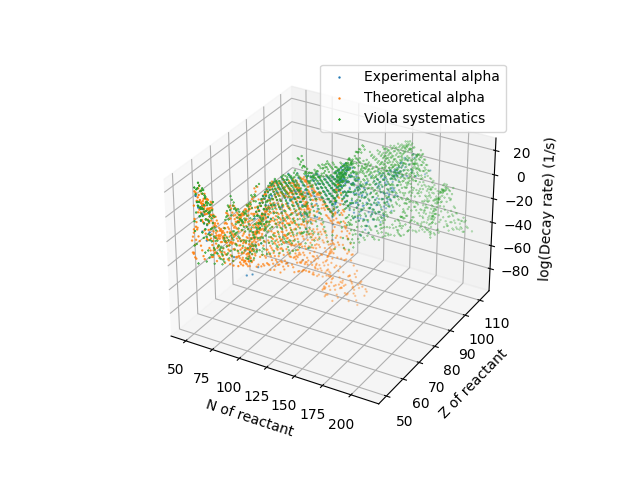

In [11]:

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(N_expa,Z_expa,np.log(lambda_expa),label='Experimental alpha',s=0.5)
ax.scatter(N_teoa,Z_teoa,np.log(lambda_teoa),label='Theoretical alpha',s=0.5)
ax.scatter(N_vioa,Z_vioa,np.log(lambda_vioa),label='Viola systematics',s=0.5, marker='x')
plt.legend()
ax.set_zlabel('log(Decay rate) (1/s)')
plt.ylabel('Z of reactant')
plt.xlabel('N of reactant')
plt.show()

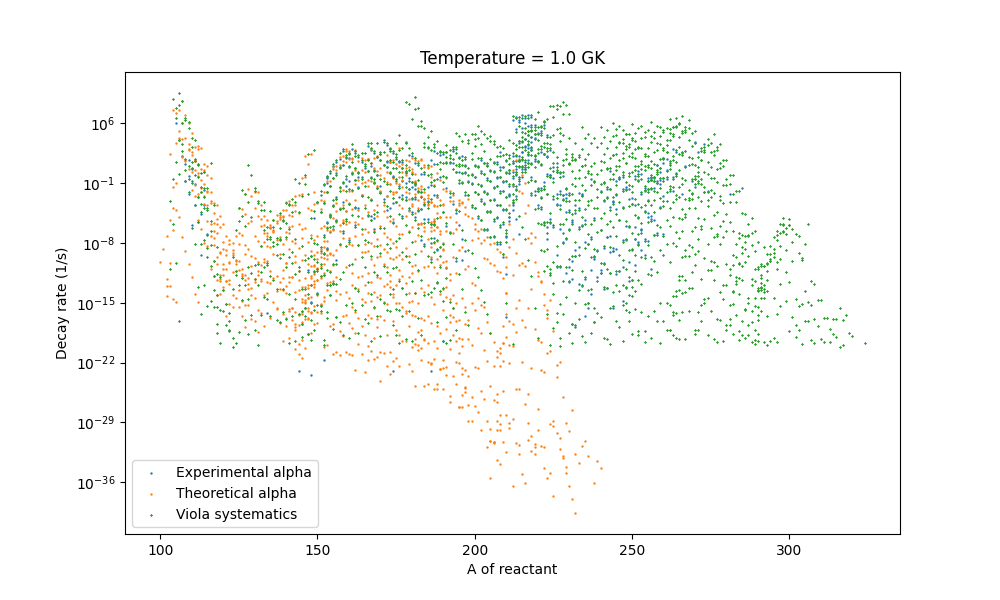

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(np.array(N_expa)+np.array(Z_expa),lambda_expa,label='Experimental alpha',s=0.5)
plt.scatter(np.array(N_teoa)+np.array(Z_teoa),lambda_teoa,label='Theoretical alpha',s=0.5)
plt.scatter(np.array(N_vioa)+np.array(Z_vioa),lambda_vioa,label='Viola systematics',s=0.5, marker='x')
plt.yscale('log')
plt.xlabel('A of reactant')
plt.title(f'Temperature = {T/1e9} GK')
plt.ylabel('Decay rate (1/s)')
plt.legend()

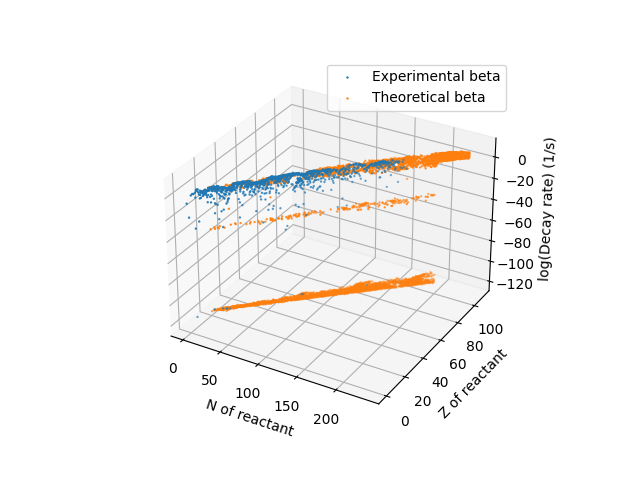

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(N_expb,Z_expb,np.log(lambda_expb),label='Experimental beta',s=0.5)
ax.scatter(N_teob,Z_teob,np.log(lambda_teob),label='Theoretical beta',s=0.5)
plt.legend()
ax.set_zlabel('log(Decay rate) (1/s)')
plt.ylabel('Z of reactant')
plt.xlabel('N of reactant')
plt.show()

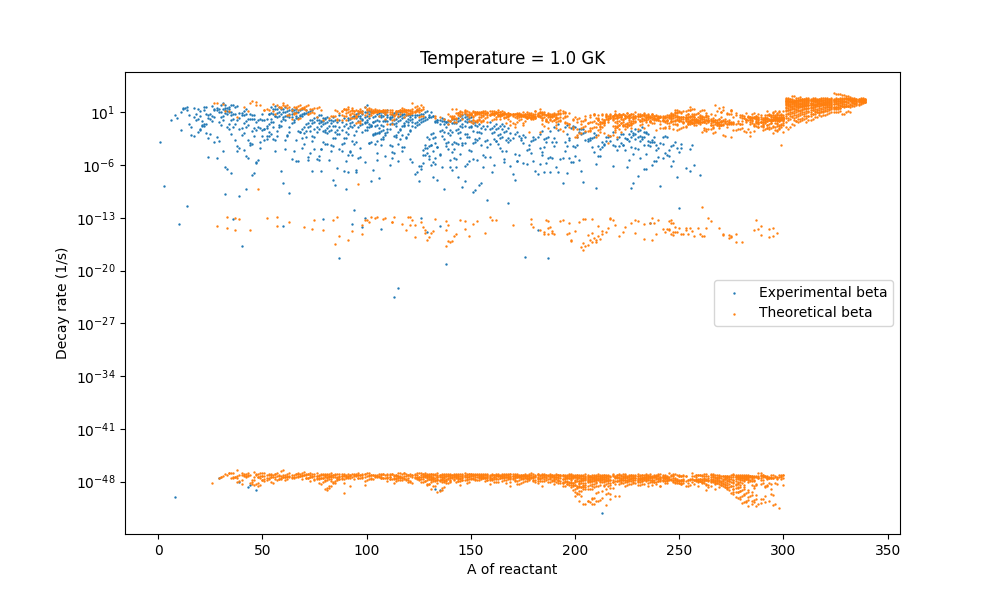

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(np.array(N_expb)+np.array(Z_expb),lambda_expb,label='Experimental beta',s=0.5)
plt.scatter(np.array(N_teob)+np.array(Z_teob),lambda_teob,label='Theoretical beta',s=0.5)
plt.yscale('log')
plt.xlabel('A of reactant')
plt.ylabel('Decay rate (1/s)')
plt.title(f'Temperature = {T/1e9} GK')
plt.legend()

In [ ]:


def reaclib2_to_reaclib1(input_file, output_file):
    """
    Convert a Reaclib v2 format file into Reaclib v1 format.
    
    Parameters
    ----------
    input_file : str or Path
        Path to Reaclib v2 file
    output_file : str or Path
        Path to write Reaclib v1 file
    """
    input_file = Path(input_file)
    output_file = Path(output_file)

    with input_file.open("r") as fin, output_file.open("w") as fout:
        header=[]
        head=0
        for line in fin:
            if len(line) != 75:
                if line[0] != head:
                    head=line[0]
                    header.append(line[0])
                    fout.write(line[0]+' '*73 + '\n')
                    fout.write(' '*74 + '\n')
                    fout.write(' '*74 + '\n')
                else:
                    continue
            else:
                fout.write(line)
   

def reaclib2_to_reaclib1_T1GK(input_file, output_file):
    """
    Convert a Reaclib v2 format file into Reaclib v1 format.
    
    Parameters
    ----------
    input_file : str or Path
        Path to Reaclib v2 file
    output_file : str or Path
        Path to write Reaclib v1 file
    """
    input_file = Path(input_file)
    output_file = Path(output_file)

    with input_file.open("r") as fin, output_file.open("w") as fout:
        header=[]
        head=0
        for line in fin:
            
            if len(line) != 75:
                if line[0] != head:
                    head=line[0]
                    header.append(line[0])
                    fout.write(line[0]+' '*73 + '\n')
                    fout.write(' '*74 + '\n')
                    fout.write(' '*74 + '\n')
                else:
                    continue
            else:
                fout.write(line)

#ile=Path(r"Nuclear_data\decays\simulations_several\reaclib_beta_exp_")
#open(file,'w')
#rates_reaclib_18_9_20.write_to_file(file)
#reaclib2_to_reaclib1(r"Nuclear_data\decays\simulations_several\reaclib_beta_exp_",
#                     r"Nuclear_data\decays\simulations_several\reaclib_beta_exp_reaclib1_")
      

In [ ]:
numero_teoricas_alpha=0
numero_teoricas_beta=0
theoretical_alpha_sources_labels=[]
theoretical_beta_sources_labels=[]
theoretical_alpha_sources=[]
theoretical_beta_sources=[]
numbera={}
numberb={}
for alpha_rate in rates_reaclib_18_9_20_alpha.get_rates():
    if alpha_rate.source['Label'] in sources_label_theoretical:
        if alpha_rate.source['Label'] not in theoretical_alpha_sources_labels:
            theoretical_alpha_sources_labels.append(alpha_rate.source['Label'])
            theoretical_alpha_sources.append(alpha_rate.source)
            numbera[alpha_rate.source['Label']]=1
        else:
            numbera[alpha_rate.source['Label']]+=1
        numero_teoricas_alpha+=1
for beta_rate in rates_reaclib_18_9_20_beta.get_rates():
    if beta_rate.source['Label'] in sources_label_theoretical:
        if beta_rate.source['Label'] not in theoretical_beta_sources_labels:
            theoretical_beta_sources_labels.append(beta_rate.source['Label'])
            theoretical_beta_sources.append(beta_rate.source)
            numberb[beta_rate.source['Label']]=1
        else:
            numberb[beta_rate.source['Label']]+=1
        numero_teoricas_beta+=1

print(theoretical_alpha_sources_labels)
print(numbera)
print(numero_teoricas_alpha)
print(theoretical_beta_sources_labels)
print(numberb)
print(numero_teoricas_beta)


In [ ]:
print(len(rates_reaclib_18_9_20_beta.get_rates()),len(rates_reaclib_18_9_20_beta_exp.get_rates()))

In [ ]:
pairsths8=[]
pairsrath=[]
pairsrk12=[]
elserates=[]
pairsmo03=[]
pairsmo92=[]

for pair in rates_reaclib_18_9_20_alpha.find_duplicate_links():
    if pair[0].source['Label']=='ths8' or pair[1].source['Label']=='ths8':
        pairsths8.append(pair)
    elif pair[0].source['Label']=='rath' or pair[1].source['Label']=='rath':
        pairsrath.append(pair)
    elif pair[0].source['Label']=='rk12' or pair[1].source['Label']=='rk12':
        pairsrk12.append(pair)
    else:
        elserates.append(pair)
for pair in rates_reaclib_18_9_20_beta.find_duplicate_links():
    if pair[0].source['Label']=='mo03' or pair[1].source['Label']=='mo03':
        pairsmo03.append(pair)
    elif pair[0].source['Label']=='mo92' or pair[1].source['Label']=='mo92':
        pairsmo92.append(pair)
    else:
        elserates.append(pair)

    


In [ ]:
print(rates_reaclib_18_9_20_beta.find_duplicate_links(),len(rates_reaclib_18_9_20_beta.get_rates()),len(rates_reaclib_18_9_20_beta_exp.get_rates()))

In [ ]:
Experimentals=[]
raths=[]
for rates in pairsrath:
    if rates[0].source['Label'] in sources_label_experimental:
        Experimentals.append(rates[0])
        raths.append(rates[1])
    elif rates[1].source['Label'] in sources_label_experimental:
        Experimentals.append(rates[1])
        raths.append(rates[0])

x=[]
y=[]
for rate in Experimentals:
    x.append(rate.eval(10**9))

for rate in raths:
    y.append(rate.eval(10**9))
    

In [ ]:
Experimentals_t=[]
ths8=[]
for rates in pairsths8:
    if rates[0].source['Label'] in sources_label_experimental:
        Experimentals_t.append(rates[0])
        ths8.append(rates[1])
    elif rates[1].source['Label'] in sources_label_experimental:
        Experimentals_t.append(rates[1])
        ths8.append(rates[0])

x1=[]
y1=[]
for rate in Experimentals_t:
    x1.append(rate.eval(10**9))

for rate in ths8:
    y1.append(rate.eval(10**9))

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
plt.figure(figsize=(15,8))
xy=np.linspace(1,len(y),len(y))
plt.scatter(xy,y,label='rath at T=10GK')
plt.scatter(xy,x,label='Experimental')
plt.yscale('log')
#plt.xscale('log')
plt.legend(frameon=False)


In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
plt.figure(figsize=(15,8))
plt.scatter(y1,label='ths8 at T=10GK')
plt.scatter(x1,label='Experimental')
plt.yscale('log')
#plt.xscale('log')
plt.legend(frameon=False)


In [ ]:
plt.figure(figsize=(15,5))
plt.plot(y1,label='ths8')
plt.plot(x1,label='Experimental')
plt.yscale('log')
#plt.xscale('log')
plt.legend()